# Case Study 1: Autonomous Vehicles: Traffic Sign Recognition (GTSRB)

**Dataset:** German Traffic Sign Recognition Benchmark (GTSRB)   
**Base model:** CNN  
**Attacks:** FGSM / PGD / ...  
**Defenses:** Adversarial Training

## Stage 0 — Setup

In [40]:
import requests, zipfile, io, os, datetime, time, json, joblib, random
from urllib.parse import urlparse
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision.models as models
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import classification_report, confusion_matrix
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
random_state=1337
torch.manual_seed(random_state)
# Seed for reproducibility
SEED = 1337
np.random.seed(SEED)
# Enforce determinism for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Stage 1 — Threat Model

- **Attacker capability:** White-box i.e., attacker has full access to the deployed traffic sign
classifier's architecture and weights (e.g. a leaked/reverse-engineered model, or an open-source model reused as-is in a commercial ADAS stack).

- **Attacker goal:** Targeted → STOP sign (class 14) misclassified as Speed Limit 120km/h (class 8). This is chosen because it's the single highest consequence misclassification pair in this dataset. A vehicle failing to recognize a stop sign as a stop sign, and instead reading it as permission to accelerate to 120km/h, converts a perception failure directly into a safety risk.

- **Real-world consequence:** A perturbed or physically-altered stop sign that an ADAS perception model misreads as a speed-limit sign would cause the vehicle to fail to stop at an intersection, directly risking collision.

## Stage 2 — Baseline Model

In [41]:
GTSRB_CLASS_NAMES = {
    0: "Speed limit (20km/h)",
    1: "Speed limit (30km/h)",
    2: "Speed limit (50km/h)",
    3: "Speed limit (60km/h)",
    4: "Speed limit (70km/h)",
    5: "Speed limit (80km/h)",
    6: "End of speed limit (80km/h)",
    7: "Speed limit (100km/h)",
    8: "Speed limit (120km/h)",
    9: "No passing",
    10: "No passing for veh over 3.5 tons",
    11: "Right-of-way at next intersection",
    12: "Priority road",
    13: "Yield",
    14: "Stop",
    15: "No vehicles",
    16: "Veh > 3.5 tons prohibited",
    17: "No entry",
    18: "General caution",
    19: "Dangerous curve left",
    20: "Dangerous curve right",
    21: "Double curve",
    22: "Bumpy road",
    23: "Slippery road",
    24: "Road narrows on the right",
    25: "Road work",
    26: "Traffic signals",
    27: "Pedestrians",
    28: "Children crossing",
    29: "Bicycles crossing",
    30: "Beware of ice/snow",
    31: "Wild animals crossing",
    32: "End speed/pass limits",
    33: "Turn right ahead",
    34: "Turn left ahead",
    35: "Ahead only",
    36: "Go straight or right",
    37: "Go straight or left",
    38: "Keep right",
    39: "Keep left",
    40: "Roundabout mandatory",
    41: "End of no passing",
    42: "End no passing veh > 3.5 tons",
}

NUM_CLASSES_GTSRB = len(GTSRB_CLASS_NAMES)  # Should be 43


def get_gtsrb_class_name(class_id):
    """
    Retrieves the human-readable name for a given GTSRB class ID.
    Args:
        class_id (int): The numeric class ID (0-42).
    Returns:
        str: The corresponding class name or an 'Unknown Class' string.
    """
    return GTSRB_CLASS_NAMES.get(class_id, f"Unknown Class {class_id}")


# Define image size and normalization constants
IMG_SIZE = 48
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD = [0.229, 0.224, 0.225]

# Our specific attack parameters
SOURCE_CLASS = 14  # Stop Sign index
TARGET_CLASS = 8  # Speed limit 120km/h index

EPSILONS = [0.0, 0.005, 0.01, 0.02, 0.03, 0.06]

print(f"\nDataset configuration:")
print(f" Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f" Number of Classes: {NUM_CLASSES_GTSRB}")
print(f" Source Class: {SOURCE_CLASS} ({get_gtsrb_class_name(SOURCE_CLASS)})")
print(f" Target Class: {TARGET_CLASS} ({get_gtsrb_class_name(TARGET_CLASS)})")

# Training transform
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

# Transform for test data
transform_test = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()])

NORM = transforms.Normalize(IMG_MEAN, IMG_STD)


Dataset configuration:
 Image Size: 48x48
 Number of Classes: 43
 Source Class: 14 (Stop)
 Target Class: 8 (Speed limit (120km/h))


In [ ]:
!hf download hf://Khalyie/gtsrb_cnn_clean --local-dir ./gtsrb
# Trained GTSRB CNN model, available on Hugging Face

class GTSRB_CNN(nn.Module):
    """
    A CNN adapted for the GTSRB dataset (43 classes, 48x48 input).
    Implements standard CNN components with adjusted layer dimensions for GTSRB.
    """

    def __init__(self, num_classes=NUM_CLASSES_GTSRB):
        super(GTSRB_CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(
            in_channels=32, out_channels=64, kernel_size=3, padding=1
        )
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(
            in_channels=64, out_channels=128, kernel_size=3, padding=1
        )
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self._feature_size = 128 * 12 * 12  # 18432
        self.fc1 = nn.Linear(self._feature_size, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv2(F.relu(self.conv1(x)))))
        x = self.pool2(F.relu(self.conv3(x)))
        x = x.view(-1, self._feature_size)  # Reshape to (Batch Size, _feature_size)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = GTSRB_CNN()
model.load_state_dict(torch.load("gtsrb/gtsrb_cnn_clean.pth", weights_only=True))
model.to(DEVICE)
model.eval()

gtsrb_data = datasets.GTSRB(root="./gtsrb",split="test", transform=transform_test, download=True)

image, label = gtsrb_data[0]
print(image.shape, label)

Hint: A new version of huggingface_hub (2.0.0) is available! You are using version 1.29.0.
To update, run: hf update
Hint: The `hf-cli` skill is not installed. Run `hf skills add -g --claude` to teach your AI agents how to use the `hf` CLI.
Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0% 0/4 [00:00<?, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.

Reconstructing (incomplete total...):   0% 0.00/46.1M [00:00<?, ?B/s]         
Reconstructing (incomplete total...):   0% 0.00/46.1M [00:00<?, ?B/s]
Reconstructing (incomplete total...):   0% 0.00/46.1M [00:00<?, ?B/s]

Fetching 4 files:  25% 1/4 [00:00<00:01,  2.46it/s]
Reconstructing (incomplete total...):  17% 7.92M/46.1M [00:02<00:12, 2.97MB/s]  


Fetching 4 files: 100% 4/4 [00:03<00:00,  1.26it/s]
Download complete: 100% 37.9M/37.9M [00:03<00:00, 34.9MB/s, 34.9MB/s  ]
Reconstruction com

100%|██████████| 89.0M/89.0M [00:01<00:00, 48.9MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 1.39MB/s]


torch.Size([3, 48, 48]) 16


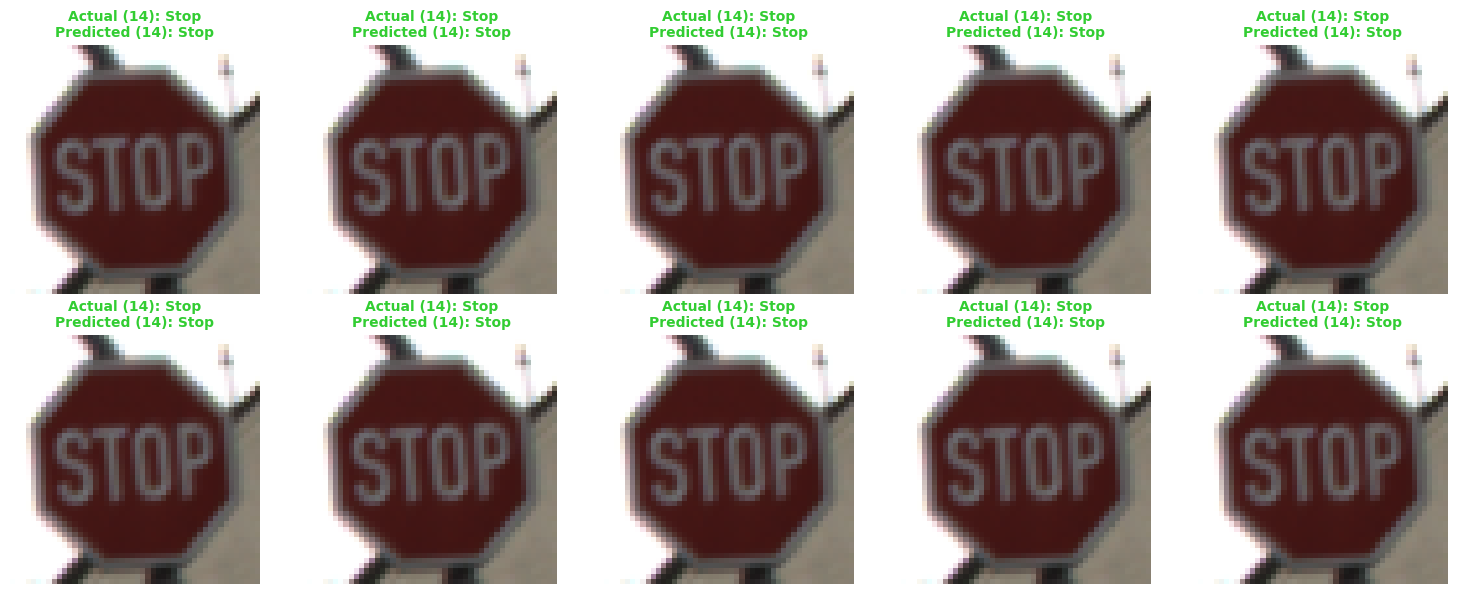

In [ ]:
# Visualize first 10 Stop Sign images
candidate_label = 14
target_label = 8
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for digit in range(10):
    for image, label in gtsrb_data:
        if label == candidate_label:
            with torch.no_grad():
                image = image.to(DEVICE)
                output = model(NORM(image.unsqueeze(0)))
                prediction = output.argmax(dim=1).item()
            ax = axes[digit // 5, digit % 5]
            ax.imshow(image.cpu().permute(1, 2, 0).clamp(0, 1))
            title_color = "red" if prediction != label else "limegreen"
            ax.set_title(f"Actual ({label}): {get_gtsrb_class_name(label)}\nPredicted ({prediction}): {get_gtsrb_class_name(prediction)}",
                         color=title_color, fontsize=10, fontweight="bold")
            ax.axis("off")
            break
plt.tight_layout()
plt.show()

In [ ]:
gtsrb_loader = DataLoader(gtsrb_data, batch_size=64, shuffle=False)

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in gtsrb_loader:
        images = images.to(DEVICE)
        outputs = model(NORM(images))
        all_preds.append(outputs.argmax(dim=1).cpu().numpy())
        all_labels.append(np.asarray(labels))

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

print(classification_report(all_labels, all_preds,
                             target_names=[get_gtsrb_class_name(i) for i in range(NUM_CLASSES_GTSRB)]))

conf_matrix = confusion_matrix(all_labels, all_preds)

                                   precision    recall  f1-score   support

             Speed limit (20km/h)       1.00      0.98      0.99        60
             Speed limit (30km/h)       0.98      0.99      0.99       720
             Speed limit (50km/h)       0.99      0.99      0.99       750
             Speed limit (60km/h)       0.98      0.94      0.96       450
             Speed limit (70km/h)       0.99      0.99      0.99       660
             Speed limit (80km/h)       0.91      0.99      0.95       630
      End of speed limit (80km/h)       0.97      0.83      0.90       150
            Speed limit (100km/h)       0.99      0.96      0.98       450
            Speed limit (120km/h)       0.99      0.96      0.97       450
                       No passing       0.99      1.00      0.99       480
 No passing for veh over 3.5 tons       1.00      0.99      1.00       660
Right-of-way at next intersection       0.92      1.00      0.96       420
                    Prio

## Stage 3 — Attack

In [ ]:
# Test on clean images (epsilon=0)
# candidate_label = 14 & target_label = 8
candidate_imgs = []
candidate_labels = []
incorrect, total = 0, 0

for original_image, original_label in gtsrb_data:
    if original_label == candidate_label:
        candidate_imgs.append(original_image)
        candidate_labels.append(original_label)

candidate_imgs = torch.stack(candidate_imgs)
candidate_labels = torch.tensor(candidate_labels)
candidate_imgs = candidate_imgs.to(DEVICE)
candidate_labels = candidate_labels.to(DEVICE)

with torch.no_grad():
    predictions = model(NORM(candidate_imgs)).argmax(dim=1)

incorrect += (predictions != candidate_labels).sum().item()
total += candidate_labels.size(0)

print(f"[*] {incorrect}/{total} STOP signs were misclassified")

[*] 0/270 STOP signs were misclassified


In [48]:
# Fast Gradient Sign Method Implementation (FGSM)
def fgsm_attack(model, images, labels, epsilon, device, targeted=False):
    """images must be RAW PIXEL SPACE, values in [0,1]."""
    images = images.clone().detach().to(device).requires_grad_(True)
    labels = labels.to(device)

    outputs = model(NORM(images))            # normalize only for the forward pass
    loss = F.cross_entropy(outputs, labels)
    model.zero_grad()
    loss.backward()

    grad_sign = images.grad.data.sign()      # gradient w.r.t. pixel image, correctly scaled by autograd
    adv_images = images - epsilon * grad_sign if targeted else images + epsilon * grad_sign
    adv_images = torch.clamp(adv_images, 0, 1)   # now trivially correct
    return adv_images.detach()

# Iterative Fast Gradient Sign Method Implementation (I-FGSM)
def ifgsm_attack(model, images, labels, epsilon, step_size, device, targeted=False):
    """Single-step FGSM attack."""
    orig_images = images.clone().detach()
    adv_images = images.clone().detach().to(device)
    labels = labels.to(device)

    alpha = epsilon/step_size

    for iter in range(step_size):
        adv_images.requires_grad_(True)
        outputs = model(NORM(adv_images))
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()

        grad_sign = adv_images.grad.data.sign()
        adv_images = adv_images - alpha * grad_sign if targeted else adv_images + alpha * grad_sign
        perturbation = torch.clamp(adv_images - orig_images, -epsilon, epsilon)
        adv_images = torch.clamp(orig_images + perturbation, 0, 1).detach()  # keep valid pixel range
    return adv_images.detach()

# Visualisation Funtions
def visualise(images, labels):
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for i in range(10):
        label = labels[i].item()
        with torch.no_grad():
            image = images[i].to(DEVICE)
            prediction = model(NORM(image.unsqueeze(0))).argmax(dim=1).item()
        ax = axes[i // 5, i % 5]
        ax.imshow(image.cpu().permute(1, 2, 0).clamp(0, 1))
        ax.set_title(f"Actual: {get_gtsrb_class_name(label)}", color="limegreen", fontsize=9, fontweight="bold")
        prediction_color = "red" if prediction != label else "limegreen"
        ax.text(1, -0.08, f"Predicted: {get_gtsrb_class_name(prediction)}", transform=ax.transAxes, ha="right",
                va="bottom", color=prediction_color, fontsize=9, fontweight="bold")
        ax.axis("off")
    #plt.tight_layout()
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    plt.show()

def visualise_targeted(images, target):
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for i in range(10):
        with torch.no_grad():
            image = images[i].to(DEVICE)
            prediction = model(NORM(image.unsqueeze(0))).argmax(dim=1).item()
        ax = axes[i // 5, i % 5]
        ax.imshow(image.cpu().permute(1, 2, 0).clamp(0, 1))
        ax.set_title(f"Target: {get_gtsrb_class_name(target)}", color="limegreen", fontsize=9, fontweight="bold")
        prediction_color = "red" if prediction != target else "limegreen"
        ax.text(1, -0.08, f"Predicted: {get_gtsrb_class_name(prediction)}", transform=ax.transAxes, ha="right",
                va="bottom", color=prediction_color, fontsize=9, fontweight="bold")
        ax.axis("off")
    #plt.tight_layout()
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    plt.show()

# Attack Success Rate (ASR) Function
def attack_success_rate(model, images, labels, attack_fn, device, **attack_kwargs):
    model.eval()
    fooled, originally_correct = 0, 0
    images, labels = images.to(device), labels.to(device)
    # Clean prediction
    with torch.no_grad():
        clean_preds = model(NORM(images)).argmax(dim=1)
    correct_mask = clean_preds == labels
    # Prediction after Adversarial Attack
    adv_images = attack_fn(model, images, labels, device=device, **attack_kwargs)
    with torch.no_grad():
        adv_preds = model(NORM(adv_images)).argmax(dim=1)
    fooled += ((adv_preds != labels) & correct_mask).sum().item()
    originally_correct += correct_mask.sum().item()
    return f"{fooled / originally_correct * 100:.2f}" if originally_correct > 0 else 0.0

# ASR Function for Targeted Attacks
def targeted_attack_success_rate(model, images, target, attack_fn, device, **attack_kwargs):
    model.eval()
    fooled, originally_correct = 0, 0
    images, target = images.to(device), target.to(device)
    # Clean prediction
    with torch.no_grad():
        clean_preds = model(NORM(images)).argmax(dim=1)
    correct_mask = clean_preds == candidate_labels
    # Prediction after Adversarial Attack
    adv_images = attack_fn(model, images, target, device=device, targeted=True, **attack_kwargs)
    with torch.no_grad():
        adv_preds = model(NORM(adv_images)).argmax(dim=1)
    fooled += (adv_preds == target).sum().item()
    originally_correct += correct_mask.sum().item()
    return f"{fooled / originally_correct * 100:.2f}" if originally_correct > 0 else 0.0


def robust_accuracy(model, data_loader, attack_fn, device, **attack_kwargs):
    model.eval()
    correct, total = 0, 0
    for images, labels in data_loader:
        images, labels = images.to(device), labels.to(device)
        adv_images = attack_fn(model, images, labels, device=device, **attack_kwargs)
        with torch.no_grad():
            outputs = model(NORM(adv_images))
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return correct / total

def epsilon_sweep(model, data_loader, attack_fn, device,
                   epsilons, step_size=20, fixed_attack_kwargs=None, metric="robust_accuracy"):
    fixed_attack_kwargs = fixed_attack_kwargs or {}
    metric_fn = robust_accuracy if metric == "robust_accuracy" else attack_success_rate

    results = []
    for eps in epsilons:
        kwargs = {**fixed_attack_kwargs, "epsilon": eps, "step_size": step_size}
        value = metric_fn(model, data_loader, attack_fn, device, **kwargs)
        results.append((eps, value))
        print(f"epsilon={eps:.4f}  {metric}={value}")
    return results

In [ ]:
# Epsilon sweep at Realistic range (roughly 1/255 to 16/255, i.e. ~0.004 to ~0.06).
ifgsm_results = epsilon_sweep(model, gtsrb_loader, ifgsm_attack, DEVICE, epsilons=EPSILONS, metric="robust_accuracy")

epsilon=0.0000  robust_accuracy=0.9737133808392716
epsilon=0.0050  robust_accuracy=0.8245447347585115
epsilon=0.0100  robust_accuracy=0.6108471892319873
epsilon=0.0200  robust_accuracy=0.3318289786223278
epsilon=0.0300  robust_accuracy=0.18551068883610453
epsilon=0.0600  robust_accuracy=0.04861441013460016


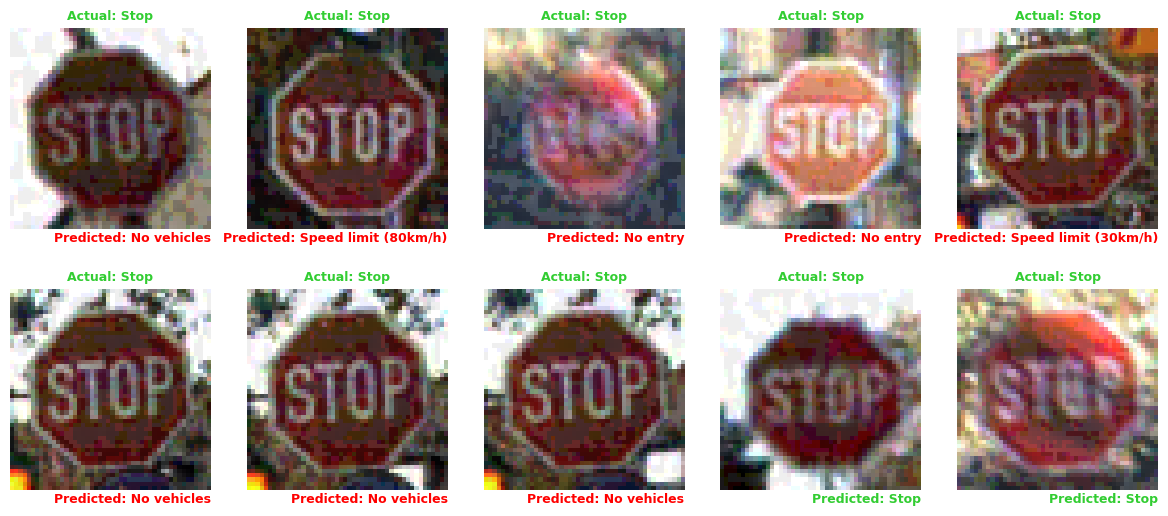

Epsilon=0.0000   Attack Success Rate: 0.00% of 270 total STOP signs predicted as Speed limit (120km/h)
Epsilon=0.0050   Attack Success Rate: 0.00% of 270 total STOP signs predicted as Speed limit (120km/h)
Epsilon=0.0100   Attack Success Rate: 7.41% of 270 total STOP signs predicted as Speed limit (120km/h)
Epsilon=0.0200   Attack Success Rate: 21.85% of 270 total STOP signs predicted as Speed limit (120km/h)
Epsilon=0.0300   Attack Success Rate: 41.85% of 270 total STOP signs predicted as Speed limit (120km/h)
Epsilon=0.0600   Attack Success Rate: 91.48% of 270 total STOP signs predicted as Speed limit (120km/h)


In [ ]:
fgsm_images = fgsm_attack(model, candidate_imgs, candidate_labels, 0.06, DEVICE)
visualise(fgsm_images, candidate_labels)

for ep in EPSILONS:
    asr = attack_success_rate(model, candidate_imgs, candidate_labels, fgsm_attack, device=DEVICE, epsilon=ep)
    print(f"Epsilon={ep:.4f}   Attack Success Rate: {asr}% of {total} total STOP signs predicted as Speed limit (120km/h)")

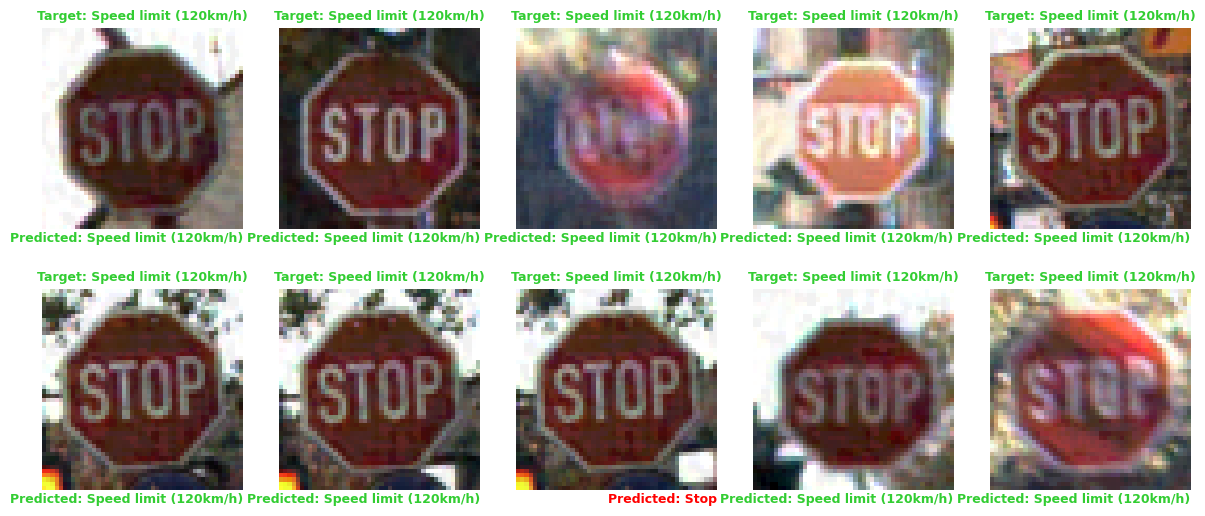

Epsilon=0.0000   Attack Success Rate: 0.00% of 270 total STOP signs predicted as Speed limit (120km/h)
Epsilon=0.0050   Attack Success Rate: 0.00% of 270 total STOP signs predicted as Speed limit (120km/h)
Epsilon=0.0100   Attack Success Rate: 0.74% of 270 total STOP signs predicted as Speed limit (120km/h)
Epsilon=0.0200   Attack Success Rate: 17.78% of 270 total STOP signs predicted as Speed limit (120km/h)
Epsilon=0.0300   Attack Success Rate: 37.04% of 270 total STOP signs predicted as Speed limit (120km/h)
Epsilon=0.0600   Attack Success Rate: 99.63% of 270 total STOP signs predicted as Speed limit (120km/h)


In [ ]:
target = torch.full((candidate_imgs.size(0),), 8, device=DEVICE, dtype=torch.long)

targeted_ifgsm_images = ifgsm_attack(model, candidate_imgs, target, epsilon=0.05, step_size=100, device=DEVICE, targeted=True)
visualise_targeted(targeted_ifgsm_images, 8)

for ep in EPSILONS:
    targeted_asr = targeted_attack_success_rate(model, candidate_imgs, target, ifgsm_attack, device=DEVICE, epsilon=ep, step_size=100)
    print(f"Epsilon={ep:.4f}   Attack Success Rate: {targeted_asr}% of {total} total STOP signs predicted as Speed limit (120km/h)")

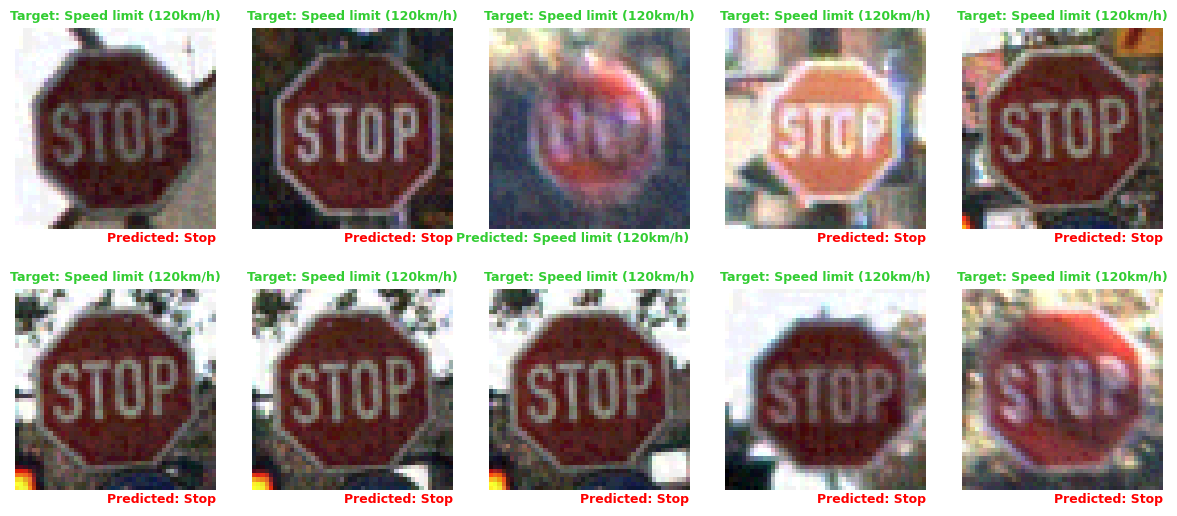

Epsilon=0.0000   Attack Success Rate: 2.58% of 270 total STOP signs predicted as Speed limit (120km/h)
Epsilon=0.0050   Attack Success Rate: 6.44% of 270 total STOP signs predicted as Speed limit (120km/h)
Epsilon=0.0100   Attack Success Rate: 8.58% of 270 total STOP signs predicted as Speed limit (120km/h)
Epsilon=0.0200   Attack Success Rate: 12.02% of 270 total STOP signs predicted as Speed limit (120km/h)
Epsilon=0.0300   Attack Success Rate: 15.45% of 270 total STOP signs predicted as Speed limit (120km/h)
Epsilon=0.0600   Attack Success Rate: 38.63% of 270 total STOP signs predicted as Speed limit (120km/h)


In [46]:
# Projected Gradient Descent (PGD)
def pgd_attack(model, images, labels, epsilon, step_size, device, targeted=True, random_start=True):
    orig_images = images.clone().detach().to(device)
    labels = labels.to(device)
    alpha = epsilon / step_size

    if random_start:
        noise = torch.empty_like(orig_images).uniform_(-epsilon, epsilon)
        adv_images = torch.clamp(orig_images + noise, 0, 1).detach()
    else:
        adv_images = orig_images.clone().detach()

    for _ in range(step_size):
        adv_images.requires_grad_(True)
        outputs = model(NORM(adv_images))
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()

        grad_sign = adv_images.grad.data.sign()
        step = -alpha * grad_sign if targeted else alpha * grad_sign
        adv_images = adv_images.detach() + step

        perturbation = torch.clamp(adv_images - orig_images, -epsilon, epsilon)
        adv_images = torch.clamp(orig_images + perturbation, 0, 1).detach()

    return adv_images

pgd_images = pgd_attack(model, candidate_imgs, target, epsilon=0.05, step_size=20, device=DEVICE, targeted=True)
visualise_targeted(pgd_images, 8)

for ep in EPSILONS:
    targeted_asr = targeted_attack_success_rate(model, candidate_imgs, target, pgd_attack, device=DEVICE, epsilon=ep, step_size=100)
    print(f"Epsilon={ep:.4f}   Attack Success Rate: {targeted_asr}% of {total} total STOP signs predicted as Speed limit (120km/h)")

## Stage 4 — Defense (Adversarial Training at Max_Epsilon 0.1)

In [ ]:
import torch
import torch.optim as optim
import torch.nn.functional as F


def adversarial_train_epoch(model, train_loader, optimizer, eps_max, device,
                             attack_fn=ifgsm_attack, step_size=20, **attack_kwargs):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        epsilon = random.uniform(0.0, eps_max)
        model.eval()
        adv_images = attack_fn(model, images, labels, epsilon=epsilon,
                                step_size=step_size, device=device, **attack_kwargs)
        model.train()

        # Train on a mix of clean + adversarial examples
        combined_images = torch.cat([images, adv_images], dim=0)
        combined_labels = torch.cat([labels, labels], dim=0)

        optimizer.zero_grad()
        outputs = model(NORM(combined_images))
        loss = F.cross_entropy(outputs, combined_labels)
        loss.backward()
        optimizer.step()

gtsrb_train_data = datasets.GTSRB(root="./gtsrb", split="train", transform=transform_train, download=True)
train_loader = DataLoader(gtsrb_train_data, batch_size=256, shuffle=True)

# Training Configuration Parameters
LEARNING_RATE = 0.001
NUM_EPOCHS = 20
WEIGHT_DECAY = 1e-4
EPS_MAX = 0.1
IFGSM_STEPS = 20

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

for epoch in range(NUM_EPOCHS):
    adversarial_train_epoch(model, train_loader, optimizer, eps_max=EPS_MAX,
                             device=DEVICE, attack_fn=ifgsm_attack, step_size=IFGSM_STEPS)
    print(f"Epoch {epoch+1} complete")

# Re-evaluate robustness after adversarial training
model.eval()
ifgsm_results = epsilon_sweep(model, gtsrb_loader, ifgsm_attack, DEVICE, epsilons=EPSILONS, metric="robust_accuracy")

Epoch 1 complete
Epoch 2 complete
